# Mapas Autoorganizados de Kohonen - Dataset 1
- Albeiro Armando Navarro Rojas
- Diego Andrés Castro Carvajal
- Isaac David Jácome García

IA, Grupo: 01

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output

## 1. Carga y Preprocesamiento de Datos
Cargar el dataset desde el archivo JSON y extraer SOLO las entradas (X). **No se usan salidas** (aprendizaje no supervisado).

In [2]:
# Nombre del archivo JSON (puedes cambiarlo)
nombre_archivo = input("Nombre del archivo JSON (ej: dataset_rbf_1.json): ") or "dataset_rbf_1.json"

with open(f'../jsons/{nombre_archivo}', 'r') as f:
    data_dict = json.load(f)

print("=== CARGA DE DATASET ===")
print(f"Dataset: {data_dict['dataset']}")
print(f"Entradas: {data_dict['features']}")
print(f"Número de patrones: {len(data_dict['data'])}")

# Extraer SOLO las entradas (no usamos salidas)
X = []
for item in data_dict['data']:
    X.append(item['input'])

X = np.array(X)

print(f"\nDimensiones:")
print(f"  X (entradas): {X.shape}")
print(f"\nNúmero de entradas: {X.shape[1]}")
print(f"Número de patrones: {X.shape[0]}")

print(f"\nPrimeros 5 patrones:")
for i in range(min(5, len(X))):
    print(f"  Patrón {i+1}: X={X[i]}")

Nombre del archivo JSON (ej: dataset_rbf_1.json):  


=== CARGA DE DATASET ===
Dataset: clasificacion_2_clases_grande
Entradas: ['x1', 'x2', 'x3', 'x4']
Número de patrones: 1000

Dimensiones:
  X (entradas): (1000, 4)

Número de entradas: 4
Número de patrones: 1000

Primeros 5 patrones:
  Patrón 1: X=[0.375 1.567 1.71  2.307]
  Patrón 2: X=[ 1.394 -0.906  1.288 -0.134]
  Patrón 3: X=[0.888 0.076 1.202 1.775]
  Patrón 4: X=[0.907 0.718 1.396 0.341]
  Patrón 5: X=[2.34  0.923 1.882 1.009]


## 2. Normalización de Datos
Normalizar los datos al rango [-1, 1] para el entrenamiento de Kohonen.

In [3]:
def normalizar_datos(X):
    """Normaliza los datos al rango [-1, 1]"""
    X_min = np.min(X, axis=0)
    X_max = np.max(X, axis=0)
    X_norm = 2 * (X - X_min) / (X_max - X_min) - 1
    return X_norm, X_min, X_max

def desnormalizar_datos(X_norm, X_min, X_max):
    """Desnormaliza los datos de [-1, 1] al rango original"""
    return (X_norm + 1) / 2 * (X_max - X_min) + X_min

X_norm, X_min, X_max = normalizar_datos(X)

print("=== NORMALIZACIÓN DE DATOS ===")
print(f"Rango original: [{np.min(X):.4f}, {np.max(X):.4f}]")
print(f"Rango normalizado: [{np.min(X_norm):.4f}, {np.max(X_norm):.4f}]")

=== NORMALIZACIÓN DE DATOS ===
Rango original: [-1.8440, 8.6480]
Rango normalizado: [-1.0000, 1.0000]


## 3. Separación del Dataset (70/15/15)
Separar el dataset en tres conjuntos: entrenamiento (70%), validación (15%) y prueba (15%).

In [4]:
n_total = len(X_norm)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

np.random.seed(42)
indices   = np.random.permutation(n_total)
train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train+n_val]
test_idx  = indices[n_train+n_val:]

X_train  = X_norm[train_idx]
X_val    = X_norm[val_idx]
X_test   = X_norm[test_idx]

print("=== SEPARACIÓN DEL DATASET ===")
print(f"Total de patrones:     {n_total}")
print(f"  Entrenamiento (70%): {n_train}")
print(f"  Validación (15%):    {n_val}")
print(f"  Prueba (15%):        {n_test}")

print("\nDimensiones:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

=== SEPARACIÓN DEL DATASET ===
Total de patrones:     1000
  Entrenamiento (70%): 700
  Validación (15%):    150
  Prueba (15%):        150

Dimensiones:
  X_train: (700, 4)
  X_val:   (150, 4)
  X_test:  (150, 4)


## 4. Configuración de la Red Kohonen
Configurar los hiperparámetros de la red Kohonen.

In [5]:
# Configurar numpy para mostrar decimales limitados
np.set_printoptions(precision=4, suppress=True)

# Parámetros configurables con valores por defecto
n_entradas = X_train.shape[1]

# Número de neuronas (debe ser par y mínimo el doble de ENTRADAS)
num_neuronas_default = max(2 * n_entradas, 4)
if num_neuronas_default % 2 != 0:
    num_neuronas_default += 1
# Limitar a un valor razonable para evitar problemas de memoria
num_neuronas_default = min(num_neuronas_default, 100)

num_neuronas = int(input(f"Número de neuronas (mínimo {num_neuronas_default}, debe ser par, máx 100): ") or str(num_neuronas_default))

# Asegurar que sea par y mínimo el doble de entradas
if num_neuronas < 2 * n_entradas:
    num_neuronas = min(2 * n_entradas, 100)
if num_neuronas % 2 != 0:
    num_neuronas += 1
if num_neuronas > 100:
    num_neuronas = 100

# Tipo de competencia
tipo_competencia = input("Tipo de competencia (blanda/dura) [blanda]: ") or "blanda"
tipo_competencia = tipo_competencia.lower()
if tipo_competencia not in ['blanda', 'dura']:
    tipo_competencia = 'blanda'

# Coeficiente de vecindad (0 < CV <= 1)
coef_vecindad = float(input("Coeficiente de vecindad (0.2): ") or "0.2")
if coef_vecindad <= 0 or coef_vecindad > 1:
    coef_vecindad = 0.2

# Número de iteraciones
num_iteraciones = int(input("Número de iteraciones (100): ") or "100")

# Tolerancia (en lugar de error objetivo)
tolerancia = float(input("Tolerancia para convergencia (0.01): ") or "0.01")

print("\n=== CONFIGURACIÓN DE LA RED KOHONEN ===")
print(f"Número de entradas:               {n_entradas}")
print(f"Número de neuronas:               {num_neuronas}")
print(f"Tipo de competencia:             {tipo_competencia}")
print(f"Coeficiente de vecindad:         {coef_vecindad}")
print(f"Número de iteraciones:           {num_iteraciones}")
print(f"Tolerancia de convergencia:      {tolerancia}")

Número de neuronas (mínimo 8, debe ser par, máx 100):  
Tipo de competencia (blanda/dura) [blanda]:  
Coeficiente de vecindad (0.2):  
Número de iteraciones (100):  
Tolerancia para convergencia (0.01):  



=== CONFIGURACIÓN DE LA RED KOHONEN ===
Número de entradas:               4
Número de neuronas:               8
Tipo de competencia:             blanda
Coeficiente de vecindad:         0.2
Número de iteraciones:           100
Tolerancia de convergencia:      0.01


## 5. Funciones Auxiliares

In [6]:
def inicializar_pesos(n_entradas, n_neuronas):
    """Inicializa los pesos sinápticos en el rango [-1, 1]"""
    return np.random.uniform(-1, 1, (n_entradas, n_neuronas))

def calcular_distancias_euclidianas(X, W):
    """Calcula la distancia euclidiana entre cada patrón y cada neurona"""
    n_patrones = X.shape[0]
    n_neuronas = W.shape[1]
    D = np.zeros((n_patrones, n_neuronas))
    
    for p in range(n_patrones):
        for n in range(n_neuronas):
            D[p, n] = np.sqrt(np.sum((X[p] - W[:, n]) ** 2))
    
    return D

def encontrar_neurona_vencedora(D):
    """Encuentra la neurona con menor distancia para cada patrón"""
    return np.argmin(D, axis=1)

def encontrar_vecinas(D_vencedora, D, coef_vecindad):
    """Encuentra las neuronas vecinas (competencia blanda)"""
    DT = D_vencedora + coef_vecindad
    vecinas = D < DT
    return vecinas

def actualizar_pesos(W, patron, indice_neurona, indices_vecinas, rata_aprendizaje):
    """Actualiza los pesos según el algoritmo de Kohonen: W = W + RA * (X - W)"""
    W_nuevo = W.copy()
    
    # Actualizar neurona vencedora: W += RA * (X - W)
    W_nuevo[:, indice_neurona] += rata_aprendizaje * (patron - W_nuevo[:, indice_neurona])
    
    # Si hay vecinas, actualizarlas también
    if indices_vecinas is not None and len(indices_vecinas) > 0:
        for idx in indices_vecinas:
            W_nuevo[:, idx] += rata_aprendizaje * (patron - W_nuevo[:, idx])
    
    return W_nuevo

def calcular_dm(D_vencedoras):
    """Calcula el promedio de las distancias vencedoras"""
    return np.mean(D_vencedoras)

def graficar_dm_historia(dm_historia, tolerancia):
    """Grafica la evolución del Dm por iteración"""
    plt.figure(figsize=(10, 5))
    plt.plot(dm_historia, marker='o', linestyle='-', linewidth=2, markersize=4)
    plt.axhline(y=tolerancia, color='r', linestyle='--', label=f'Tolerancia ({tolerancia})')
    plt.xlabel('Iteración')
    plt.ylabel('Dm (Promedio de distancias vencedoras)')
    plt.title('Evolución del Dm durante el entrenamiento')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def graficar_pesos(W, iteracion):
    """Grafica el comportamiento de los pesos sinápticos como heatmap"""
    plt.figure(figsize=(12, 8))
    sns.heatmap(W, annot=True, fmt='.4f', cmap='coolwarm', center=0,
                xticklabels=[f'N{i+1}' for i in range(W.shape[1])],
                yticklabels=[f'E{i+1}' for i in range(W.shape[0])])
    plt.xlabel('Neurona')
    plt.ylabel('Entrada')
    plt.title(f'Matriz de Pesos Sinápticos - Iteración {iteracion}')
    plt.tight_layout()
    plt.show()

def graficar_matriz_pesos_personalizada(W_historia, iteracion):
    """Grafica la matriz de pesos de una iteración específica"""
    if iteracion < 0 or iteracion >= len(W_historia):
        print(f"Error: iteración {iteracion} fuera de rango (0-{len(W_historia)-1})")
        return
    
    W = W_historia[iteracion]
    plt.figure(figsize=(12, 8))
    sns.heatmap(W, annot=True, fmt='.4f', cmap='coolwarm', center=0,
                xticklabels=[f'N{i+1}' for i in range(W.shape[1])],
                yticklabels=[f'E{i+1}' for i in range(W.shape[0])])
    plt.xlabel('Neurona')
    plt.ylabel('Entrada')
    plt.title(f'Matriz de Pesos Sinápticos - Iteración {iteracion}')
    plt.tight_layout()
    plt.show()

def guardar_pesos_como_texto(W, nombre_archivo="pesos_sinapticos.txt"):
    """Guarda la matriz de pesos como texto en formato array de arrays"""
    with open(nombre_archivo, 'w') as f:
        f.write("# Matriz de Pesos Sinápticos\n")
        f.write(f"# Dimensiones: {W.shape[0]} entradas x {W.shape[1]} neuronas\n")
        f.write(f"# Formato: [[pesos_neurona_1], [pesos_neurona_2], ...]\n\n")
        
        f.write("W = [\n")
        for n in range(W.shape[1]):
            pesos_neurona = W[:, n]
            f.write(f"  [{', '.join([f'{p:.6f}' for p in pesos_neurona])}]")
            if n < W.shape[1] - 1:
                f.write(",\n")
            else:
                f.write("\n")
        f.write("]\n")
    
    print(f"Pesos guardados en: {nombre_archivo}")

def simular_kohonen(X, W):
    """Simula la red Kohonen: encuentra la neurona vencedora para cada patrón"""
    D = calcular_distancias_euclidianas(X, W)
    indices_vencedores = encontrar_neurona_vencedora(D)
    distancias_vencedoras = D[np.arange(len(X)), indices_vencedores]
    return indices_vencedores, distancias_vencedoras

print("=== FUNCIONES AUXILIARES DEFINIDAS ===")

=== FUNCIONES AUXILIARES DEFINIDAS ===


## 6. Entrenamiento de la Red Kohonen
Entrenamiento iterativo con actualización dinámica de la rata de aprendizaje.

In [7]:
print("=== ENTRENAMIENTO DE LA RED KOHONEN ===\n")

# Inicializar pesos
np.random.seed(42)
W = inicializar_pesos(n_entradas, num_neuronas)

# Historia para gráficas
dm_historia = []
W_historia = []  # Guardar matriz de pesos en CADA iteración

# Guardar mejor configuración
mejor_W = W.copy()
mejor_dm = float('inf')

convergio = False
iteracion_convergencia = -1

# Intervalo para mostrar detalles detallados
intervalo_detalle = 10  # Mostrar detalles cada 10 iteraciones

print(f"Iteración 0 - Matriz de pesos inicial:")
print(W)
W_historia.append(W.copy())

for iteracion in range(1, num_iteraciones + 1):
    # Rata de aprendizaje dinámica: RA = 1/iteración
    rata_aprendizaje = 1.0 / iteracion
    
    # Distancias vencedoras de esta iteración
    D_vencedoras_iter = []
    
    # Mostrar detalle detallado en intervalos
    mostrar_detalle = (iteracion % intervalo_detalle == 0)
    
    if mostrar_detalle:
        print(f"\n{'='*60}")
        print(f"ITERACIÓN {iteracion}/{num_iteraciones}")
        print(f"{'='*60}")
        print(f"FÓRMULAS:")
        print(f"  RA (rata aprendizaje) = 1/iteración = {rata_aprendizaje:.6f}")
        print(f"  CV (coeficiente vecindad) = {coef_vecindad}")
        print(f"\nProcesando {len(X_train)} patrones...")
    
    # Presentar cada patrón
    for p in range(len(X_train)):
        patron = X_train[p]
        
        # Calcular distancias a todas las neuronas
        D_patron = np.zeros(num_neuronas)
        for n in range(num_neuronas):
            D_patron[n] = np.sqrt(np.sum((patron - W[:, n]) ** 2))
        
        # Encontrar neurona vencedora
        indice_vencedor = np.argmin(D_patron)
        D_vencedora = D_patron[indice_vencedor]
        D_vencedoras_iter.append(D_vencedora)
        
        # Competencia blanda o dura
        if tipo_competencia == 'blanda':
            # Encontrar vecinas
            DT = D_vencedora + coef_vecindad
            indices_vecinas = np.where(D_patron < DT)[0]
            # Excluir la vencedora de las vecinas para no actualizarla dos veces
            indices_vecinas = indices_vecinas[indices_vecinas != indice_vencedor]
        else:
            # Competencia dura: solo la vencedora
            indices_vecinas = None
        
        # Actualizar pesos con FÓRMULA CORRECTA: W = W + RA * (X - W)
        delta = rata_aprendizaje * (patron - W[:, indice_vencedor])
        W[:, indice_vencedor] += delta
        
        if indices_vecinas is not None and len(indices_vecinas) > 0:
            for idx in indices_vecinas:
                delta_vecina = rata_aprendizaje * (patron - W[:, idx])
                W[:, idx] += delta_vecina
        
        # Mostrar detalle del primer patrón en iteraciones con detalle
        if mostrar_detalle and p == 0:
            print(f"\n  Ejemplo - Patrón {p+1}:")
            print(f"    X = [{', '.join([f'{x:.4f}' for x in patron])}]")
            print(f"    Distancias a neuronas: min={D_vencedora:.6f}, max={np.max(D_patron):.6f}")
            print(f"    Neurona vencedora: N{indice_vencedor+1}")
            print(f"    Actualización: Δ = RA * (X - W) = {rata_aprendizaje:.6f} * (X - W)")
            print(f"    Δ = [{', '.join([f'{d:.6f}' for d in delta])}]")
            if indices_vecinas is not None and len(indices_vecinas) > 0:
                print(f"    Vecinas actualizadas: {len(indices_vecinas)} neuronas")
            else:
                print(f"    Vecinas actualizadas: 0 (competencia dura)")
    
    # Calcular Dm (promedio de distancias vencedoras)
    dm = np.mean(D_vencedoras_iter)
    dm_historia.append(dm)
    
    # Guardar pesos en CADA iteración
    W_historia.append(W.copy())
    
    # Verificar si es el mejor Dm
    if dm < mejor_dm:
        mejor_dm = dm
        mejor_W = W.copy()
    
    # Mostrar resumen de la iteración con detalle
    if mostrar_detalle:
        print(f"\n  RESUMEN ITERACIÓN {iteracion}:")
        print(f"    Dm (promedio distancias) = {dm:.6f}")
        print(f"    Mejor Dm histórico = {mejor_dm:.6f}")
        print(f"    Tolerancia objetivo = {tolerancia}")
        if dm <= tolerancia:
            print(f"    ✓ Dm ≤ Tolerancia (CONVERGIÓ)")
        else:
            print(f"    ✗ Dm > Tolerancia (continúa)")
    
    # Verificar convergencia
    if dm <= tolerancia:
        convergio = True
        iteracion_convergencia = iteracion
        print(f"\n{'='*60}")
        print(f"✓ CONVERGIÓ en la iteración {iteracion}")
        print(f"{'='*60}")
        print(f"  Dm final: {dm:.6f}")
        print(f"  Tolerancia: {tolerancia}")
        print(f"\nMatriz de pesos final:")
        print(W)
        break
    
    # Mostrar progreso simple cada 5 iteraciones (sin detalle completo)
    if iteracion % 5 == 0 and not mostrar_detalle:
        print(f"Iteración {iteracion}/{num_iteraciones} - Dm: {dm:.6f} - RA: {rata_aprendizaje:.4f}")

if not convergio:
    print(f"\n{'='*60}")
    print(f"✗ NO convergió después de {num_iteraciones} iteraciones")
    print(f"{'='*60}")
    print(f"  Dm final: {dm:.6f}")
    print(f"  Mejor Dm: {mejor_dm:.6f}")
    print(f"  Tolerancia: {tolerancia}")
    print(f"\nMatriz de pesos final:")
    print(W)

=== ENTRENAMIENTO DE LA RED KOHONEN ===

Iteración 0 - Matriz de pesos inicial:
[[-0.2509  0.9014  0.464   0.1973 -0.688  -0.688  -0.8838  0.7324]
 [ 0.2022  0.4161 -0.9588  0.9398  0.6649 -0.5753 -0.6364 -0.6332]
 [-0.3915  0.0495 -0.1361 -0.4175  0.2237 -0.721  -0.4157 -0.2673]
 [-0.0879  0.5704 -0.6007  0.0285  0.1848 -0.9071  0.2151 -0.659 ]]
Iteración 5/100 - Dm: 0.322426 - RA: 0.2000

ITERACIÓN 10/100
FÓRMULAS:
  RA (rata aprendizaje) = 1/iteración = 0.100000
  CV (coeficiente vecindad) = 0.2

Procesando 700 patrones...

  Ejemplo - Patrón 1:
    X = [0.2927, 0.4435, 0.4127, 0.5068]
    Distancias a neuronas: min=0.275841, max=1.783102
    Neurona vencedora: N2
    Actualización: Δ = RA * (X - W) = 0.100000 * (X - W)
    Δ = [-0.026803, 0.000969, -0.006398, -0.000792]
    Vecinas actualizadas: 2 neuronas

  RESUMEN ITERACIÓN 10:
    Dm (promedio distancias) = 0.314521
    Mejor Dm histórico = 0.314521
    Tolerancia objetivo = 0.01
    ✗ Dm > Tolerancia (continúa)
Iteración 15/10

print("\n=== MATRIZ DE PESOS SINÁPTICOS (FORMATO TEXTO) ===")
print(f"Dimensiones: {W.shape[0]} entradas x {W.shape[1]} neuronas\n")
print("W = [")
for n in range(W.shape[1]):
    pesos_neurona = W[:, n]
    print(f"  [{', '.join([f'{p:.6f}' for p in pesos_neurona])}]", end="")
    if n < W.shape[1] - 1:
        print(",")
    else:
        print("\n]")
print()

# Graficar evolución del Dm
graficar_dm_historia(dm_historia, tolerancia)

# Graficar comportamiento de pesos (último estado)
graficar_pesos(W, iteracion if convergio else num_iteraciones)

## 8. Evaluación en Train, Val y Test
Evaluar la red entrenada en los tres conjuntos.

In [8]:
print("=== EVALUACIÓN DE LA RED KOHONEN ===\n")

# Usar los mejores pesos
W_final = mejor_W

# Evaluar en Train
indices_vencedores_train, distancias_train = simular_kohonen(X_train, W_final)
dm_train = np.mean(distancias_train)

# Evaluar en Val
indices_vencedores_val, distancias_val = simular_kohonen(X_val, W_final)
dm_val = np.mean(distancias_val)

# Evaluar en Test
indices_vencedores_test, distancias_test = simular_kohonen(X_test, W_final)
dm_test = np.mean(distancias_test)

print(f"  {'Conjunto':<18} {'Dm':<12} {'Patrones':<10}")
print(f"  {'-'*40}")
print(f"  {'Train (70%)':<18} {dm_train:<12.6f} {len(X_train):<10}")
print(f"  {'Validation (15%)':<18} {dm_val:<12.6f} {len(X_val):<10}")
print(f"  {'Test (15%)':<18} {dm_test:<12.6f} {len(X_test):<10}")

# Distribución de neuronas vencedoras
print(f"\n=== DISTRIBUCIÓN DE NEURONAS VENCEDORAS ===")
print(f"\nTrain:")
for n in range(num_neuronas):
    conteo = np.sum(indices_vencedores_train == n)
    porcentaje = (conteo / len(X_train)) * 100
    print(f"  Neurona {n+1}: {conteo:4d} patrones ({porcentaje:5.2f}%)")

print(f"\nValidation:")
for n in range(num_neuronas):
    conteo = np.sum(indices_vencedores_val == n)
    porcentaje = (conteo / len(X_val)) * 100
    print(f"  Neurona {n+1}: {conteo:4d} patrones ({porcentaje:5.2f}%)")

print(f"\nTest:")
for n in range(num_neuronas):
    conteo = np.sum(indices_vencedores_test == n)
    porcentaje = (conteo / len(X_test)) * 100
    print(f"  Neurona {n+1}: {conteo:4d} patrones ({porcentaje:5.2f}%)")

=== EVALUACIÓN DE LA RED KOHONEN ===

  Conjunto           Dm           Patrones  
  ----------------------------------------
  Train (70%)        0.307287     700       
  Validation (15%)   0.293549     150       
  Test (15%)         0.303224     150       

=== DISTRIBUCIÓN DE NEURONAS VENCEDORAS ===

Train:
  Neurona 1:  359 patrones (51.29%)
  Neurona 2:  341 patrones (48.71%)
  Neurona 3:    0 patrones ( 0.00%)
  Neurona 4:    0 patrones ( 0.00%)
  Neurona 5:    0 patrones ( 0.00%)
  Neurona 6:    0 patrones ( 0.00%)
  Neurona 7:    0 patrones ( 0.00%)
  Neurona 8:    0 patrones ( 0.00%)

Validation:
  Neurona 1:   56 patrones (37.33%)
  Neurona 2:   94 patrones (62.67%)
  Neurona 3:    0 patrones ( 0.00%)
  Neurona 4:    0 patrones ( 0.00%)
  Neurona 5:    0 patrones ( 0.00%)
  Neurona 6:    0 patrones ( 0.00%)
  Neurona 7:    0 patrones ( 0.00%)
  Neurona 8:    0 patrones ( 0.00%)

Test:
  Neurona 1:   85 patrones (56.67%)
  Neurona 2:   65 patrones (43.33%)
  Neurona 3:    0 

## 9. Gráfica de Distribución de Neuronas

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train
conteos_train = [np.sum(indices_vencedores_train == n) for n in range(num_neuronas)]
axes[0].bar(range(1, num_neuronas + 1), conteos_train, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Neurona')
axes[0].set_ylabel('Número de patrones')
axes[0].set_title(f'Train - Dm: {dm_train:.6f}')
axes[0].grid(True, alpha=0.3)

# Val
conteos_val = [np.sum(indices_vencedores_val == n) for n in range(num_neuronas)]
axes[1].bar(range(1, num_neuronas + 1), conteos_val, color='coral', alpha=0.8)
axes[1].set_xlabel('Neurona')
axes[1].set_ylabel('Número de patrones')
axes[1].set_title(f'Validation - Dm: {dm_val:.6f}')
axes[1].grid(True, alpha=0.3)

# Test
conteos_test = [np.sum(indices_vencedores_test == n) for n in range(num_neuronas)]
axes[2].bar(range(1, num_neuronas + 1), conteos_test, color='mediumseagreen', alpha=0.8)
axes[2].set_xlabel('Neurona')
axes[2].set_ylabel('Número de patrones')
axes[2].set_title(f'Test - Dm: {dm_test:.6f}')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Ajuste Manual de Parámetros (opcional)
Si quieres cambiar la configuración antes de reentrenar, modifica aquí y re-ejecuta desde la celda 4.

In [9]:
# Descomenta y modifica los valores que quieras ajustar:
# num_neuronas = 8
# tipo_competencia = "blanda"  # o "dura"
# coef_vecindad = 0.2
# num_iteraciones = 100
# tolerancia = 0.01

print("=== AJUSTE MANUAL ===")
print(f"  num_neuronas:     {num_neuronas}")
print(f"  tipo_competencia: {tipo_competencia}")
print(f"  coef_vecindad:    {coef_vecindad}")
print(f"  num_iteraciones:  {num_iteraciones}")
print(f"  tolerancia:       {tolerancia}")

=== AJUSTE MANUAL ===
  num_neuronas:     8
  tipo_competencia: blanda
  coef_vecindad:    0.2
  num_iteraciones:  100
  tolerancia:       0.01


## 11. Reentrenamiento (si no convergió)
Si la red no convergió, podemos reentrenar con diferentes estrategias.

In [10]:
if not convergio:
    print("=== REENTRENAMIENTO ===\n")
    
    # Analizar comportamiento del Dm
    dm_ultimas_10 = dm_historia[-10:] if len(dm_historia) >= 10 else dm_historia
    tendencia = "decreciente" if dm_ultimas_10[0] > dm_ultimas_10[-1] else "creciente"
    
    print(f"Análisis de Dm: {tendencia}")
    print(f"  Último Dm: {dm_historia[-1]:.6f}")
    print(f"  Mejor Dm: {mejor_dm:.6f}")
    
    if tendencia == "decreciente":
        print("\n→ El Dm está disminuyendo. Continuamos con los pesos actuales.")
        W_reentrenamiento = mejor_W.copy()
        print("  Usando pesos del entrenamiento anterior.")
    else:
        print("\n→ El Dm está aumentando o estancado. Reinicializamos la red.")
        print("  Aumentando número de neuronas.")
        
        # Aumentar número de neuronas
        num_neuronas_re = min(num_neuronas + 2, 100)
        print(f"  Nuevas neuronas: {num_neuronas} → {num_neuronas_re}")
        
        # Reinicializar pesos
        np.random.seed(100)
        W_reentrenamiento = inicializar_pesos(n_entradas, num_neuronas_re)
        
        # Actualizar variable global
        num_neuronas = num_neuronas_re
    
    # Reentrenar
    print("\nIniciando reentrenamiento...\n")
    
    dm_historia_re = []
    W_historia_re = []
    mejor_dm_re = float('inf')
    mejor_W_re = W_reentrenamiento.copy()
    
    convergio_re = False
    
    W_historia_re.append(W_reentrenamiento.copy())
    
    for iteracion in range(1, num_iteraciones + 1):
        rata_aprendizaje = 1.0 / iteracion
        D_vencedoras_iter = []
        
        for p in range(len(X_train)):
            patron = X_train[p]
            D_patron = np.zeros(num_neuronas)
            for n in range(num_neuronas):
                D_patron[n] = np.sqrt(np.sum((patron - W_reentrenamiento[:, n]) ** 2))
            
            indice_vencedor = np.argmin(D_patron)
            D_vencedora = D_patron[indice_vencedor]
            D_vencedoras_iter.append(D_vencedora)
            
            if tipo_competencia == 'blanda':
                DT = D_vencedora + coef_vecindad
                indices_vecinas = np.where(D_patron < DT)[0]
                indices_vecinas = indices_vecinas[indices_vecinas != indice_vencedor]
            else:
                indices_vecinas = None
            
            # FÓRMULA CORRECTA: W = W + RA * (X - W)
            W_reentrenamiento[:, indice_vencedor] += rata_aprendizaje * (patron - W_reentrenamiento[:, indice_vencedor])
            if indices_vecinas is not None and len(indices_vecinas) > 0:
                for idx in indices_vecinas:
                    W_reentrenamiento[:, idx] += rata_aprendizaje * (patron - W_reentrenamiento[:, idx])
        
        dm = np.mean(D_vencedoras_iter)
        dm_historia_re.append(dm)
        W_historia_re.append(W_reentrenamiento.copy())
        
        if dm < mejor_dm_re:
            mejor_dm_re = dm
            mejor_W_re = W_reentrenamiento.copy()
        
        if dm <= tolerancia:
            convergio_re = True
            print(f"✓ CONVERGIÓ en la iteración {iteracion}")
            print(f"  Dm final: {dm:.6f}")
            break
        
        if iteracion % 10 == 0:
            print(f"Iteración {iteracion}/{num_iteraciones} - Dm: {dm:.6f}")
    
    if not convergio_re:
        print(f"\n✗ NO convergió después de {num_iteraciones} iteraciones")
        print(f"  Mejor Dm: {mejor_dm_re:.6f}")
    
    # Comparación
    print(f"\n=== COMPARACIÓN ===")
    print(f"  {'Métrica':<20} {'Entrenamiento':<15} {'Reentrenamiento':<15}")
    print(f"  {'-'*50}")
    print(f"  {'Mejor Dm':<20} {mejor_dm:<15.6f} {mejor_dm_re:<15.6f}")
    print(f"  {'Convergió':<20} {'Sí' if convergio else 'No':<15} {'Sí' if convergio_re else 'No':<15}")
    
    # Usar los mejores pesos del reentrenamiento
    W_final = mejor_W_re
    W_historia = W_historia_re
else:
    print("\nLa red ya convergió en el primer entrenamiento. No es necesario reentrenar.")

=== REENTRENAMIENTO ===

Análisis de Dm: decreciente
  Último Dm: 0.308207
  Mejor Dm: 0.308207

→ El Dm está disminuyendo. Continuamos con los pesos actuales.
  Usando pesos del entrenamiento anterior.

Iniciando reentrenamiento...

Iteración 10/100 - Dm: 0.314521
Iteración 20/100 - Dm: 0.311098
Iteración 30/100 - Dm: 0.309979
Iteración 40/100 - Dm: 0.309391
Iteración 50/100 - Dm: 0.309019
Iteración 60/100 - Dm: 0.308760
Iteración 70/100 - Dm: 0.308569
Iteración 80/100 - Dm: 0.308422
Iteración 90/100 - Dm: 0.308304
Iteración 100/100 - Dm: 0.308207

✗ NO convergió después de 100 iteraciones
  Mejor Dm: 0.308207

=== COMPARACIÓN ===
  Métrica              Entrenamiento   Reentrenamiento
  --------------------------------------------------
  Mejor Dm             0.308207        0.308207       
  Convergió            No              No             


## 12. Simulación
Simular la red con un patrón específico (conocido o desconocido).

In [11]:
print("=== SIMULACIÓN ===\n")

# Seleccionar un patrón de test para simular
indice_patron = int(input(f"Índice del patrón de test (0-{len(X_test)-1}): ") or "0")
patron_original = X_test[indice_patron]

# Normalizar el patrón si no está normalizado
patron = patron_original  # Ya está normalizado

print(f"Patrón seleccionado: {patron}")

# Calcular distancias a todas las neuronas
D_patron = np.zeros(num_neuronas)
for n in range(num_neuronas):
    D_patron[n] = np.sqrt(np.sum((patron - W_final[:, n]) ** 2))

# Encontrar neurona vencedora
indice_vencedor = np.argmin(D_patron)
D_vencedora = D_patron[indice_vencedor]

print(f"\nDistancias a cada neurona:")
for n in range(num_neuronas):
    print(f"  Neurona {n+1}: {D_patron[n]:.6f}")

print(f"\n✓ Neurona vencedora: Neurona {indice_vencedor + 1}")
print(f"  Distancia: {D_vencedora:.6f}")

# La salida de la red son los pesos de la neurona vencedora
salida_red = W_final[:, indice_vencedor]
print(f"\nSalida de la red (pesos de la neurona vencedora):")
print(f"  {salida_red}")

# Desnormalizar para mostrar en escala original
salida_original = desnormalizar_datos(salida_red.reshape(1, -1), X_min, X_max)[0]
print(f"\nSalida desnormalizada (escala original):")
print(f"  {salida_original}")

=== SIMULACIÓN ===



Índice del patrón de test (0-149):  45


Patrón seleccionado: [-0.4881 -0.797  -0.2905 -0.448 ]

Distancias a cada neurona:
  Neurona 1: 0.371756
  Neurona 2: 2.025820
  Neurona 3: 0.371756
  Neurona 4: 2.025820
  Neurona 5: 2.025820
  Neurona 6: 0.371756
  Neurona 7: 0.371756
  Neurona 8: 0.371756

✓ Neurona vencedora: Neurona 1
  Distancia: 0.371756

Salida de la red (pesos de la neurona vencedora):
  [-0.4707 -0.5382 -0.5565 -0.4348]

Salida desnormalizada (escala original):
  [1.0674 1.0013 1.0312 1.0176]


## 13. Resumen Final

## 14. Graficar Matriz de Pesos a Elección
Grafica la matriz de pesos de cualquier iteración del entrenamiento.

=== GRAFICAR MATRIZ DE PESOS A ELECCIÓN ===

Total de iteraciones guardadas: 101
(La iteración 0 es la matriz inicial, la última es la matriz final)



Ingresa el número de iteración a graficar (0-100):  34



Selecciona el conjunto de patrones:
  1. Train
  2. Validation
  3. Test


Opción (1-3) [1]:  

Índice del patrón de Train (0-699):  34



INFORMACIÓN DETALLADA

📊 DATASET Y CONJUNTO:
  Dataset: clasificacion_2_clases_grande
  Conjunto seleccionado: Train
  Total de patrones en Train: 700

🎯 PATRÓN SELECCIONADO:
  Índice del patrón: 34
  Valores del patrón (normalizado): [-0.527943, -0.738462, -0.423725, -0.633024]
  Valores del patrón (original): [0.7830, 0.0120, 1.6810, 0.0140]

🔄 ITERACIÓN SELECCIONADA:
  Número de iteración: 34
  Estado: Matriz de pesos durante el entrenamiento

🧠 NEURONA VENCEDORA:
  Neurona ganadora: N1
  Distancia a la neurona ganadora: 0.332551
  Columna correspondiente en la matriz: 0

📈 DISTANCIAS A TODAS LAS NEURONAS:
  Neurona 1: 0.332551 ⭐ GANADORA
  Neurona 2: 2.155933
  Neurona 3: 0.332551
  Neurona 4: 2.155933
  Neurona 5: 2.155933
  Neurona 6: 0.332551
  Neurona 7: 0.332551
  Neurona 8: 0.332551

🔢 MATRIZ DE PESOS SINÁPTICOS (Iteración 34):
  Dimensiones: 4 entradas x 8 neuronas
  Formato: Cada columna representa los pesos de una neurona

W = [
  [-0.452858, -0.522511, -0.565788, -0.4377

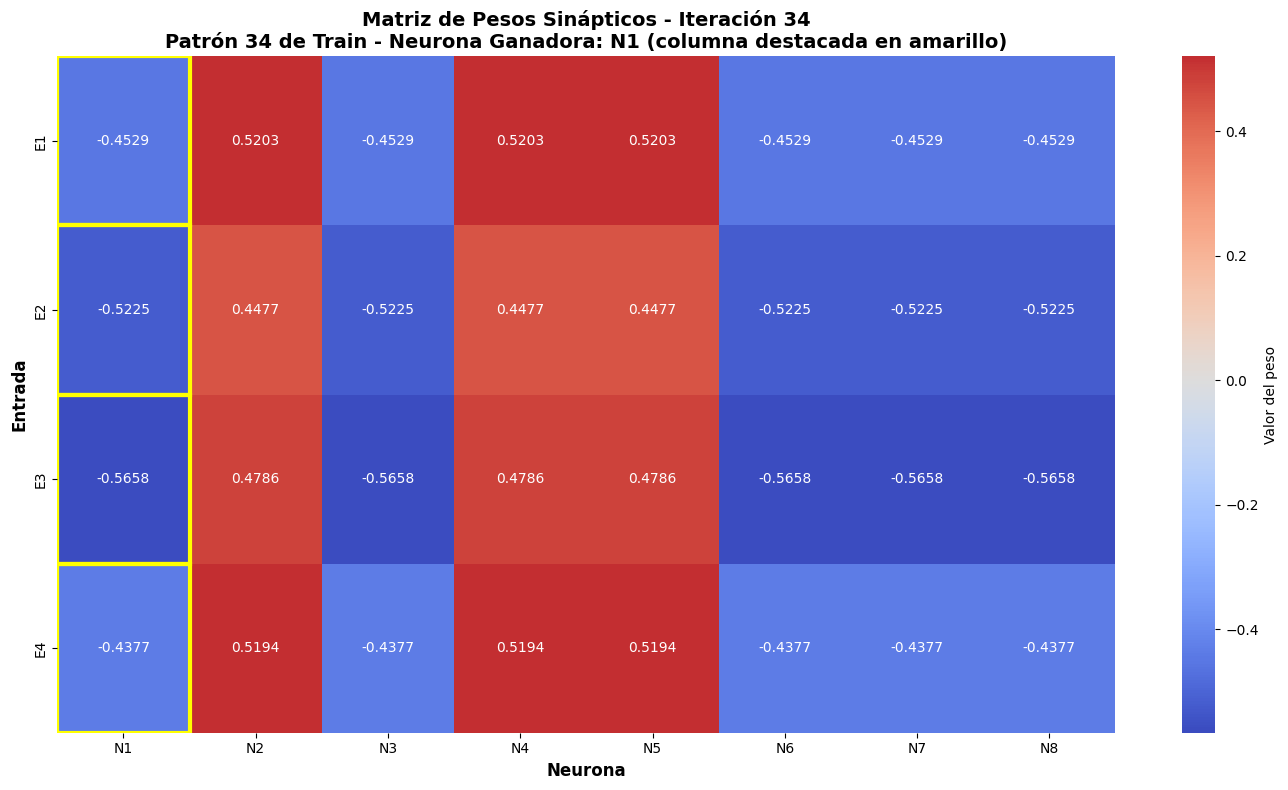

In [12]:
print("=== GRAFICAR MATRIZ DE PESOS A ELECCIÓN ===\n")
print(f"Total de iteraciones guardadas: {len(W_historia)}")
print(f"(La iteración 0 es la matriz inicial, la última es la matriz final)\n")

# Seleccionar iteración
iteracion_elegida = int(input(f"Ingresa el número de iteración a graficar (0-{len(W_historia)-1}): "))

# Seleccionar conjunto (train, val, o test)
print("\nSelecciona el conjunto de patrones:")
print("  1. Train")
print("  2. Validation")
print("  3. Test")
conjunto_opcion = input("Opción (1-3) [1]: ") or "1"

if conjunto_opcion == "1":
    X_conjunto = X_train
    nombre_conjunto = "Train"
elif conjunto_opcion == "2":
    X_conjunto = X_val
    nombre_conjunto = "Validation"
else:
    X_conjunto = X_test
    nombre_conjunto = "Test"

# Validar el índice del patrón
max_indice_patron = len(X_conjunto) - 1
while True:
    try:
        indice_patron_str = input(f"\nÍndice del patrón de {nombre_conjunto} (0-{max_indice_patron}): ")
        indice_patron = int(indice_patron_str) if indice_patron_str else 0
        if 0 <= indice_patron <= max_indice_patron:
            break
        else:
            print(f"Error: El índice debe estar entre 0 y {max_indice_patron}.")
    except ValueError:
        print("Error: Ingresa un número válido para el índice del patrón.")

patron = X_conjunto[indice_patron]

# Obtener matriz de pesos de la iteración seleccionada
W_iteracion = W_historia[iteracion_elegida]

# Calcular distancias del patrón a cada neurona
D_patron = np.zeros(num_neuronas)
for n in range(num_neuronas):
    D_patron[n] = np.sqrt(np.sum((patron - W_iteracion[:, n]) ** 2))

# Encontrar neurona vencedora
indice_vencedor = np.argmin(D_patron)
D_vencedora = D_patron[indice_vencedor]

print("\n" + "="*70)
print("INFORMACIÓN DETALLADA")
print("="*70)
print(f"\n📊 DATASET Y CONJUNTO:")
print(f"  Dataset: {data_dict['dataset']}")
print(f"  Conjunto seleccionado: {nombre_conjunto}")
print(f"  Total de patrones en {nombre_conjunto}: {len(X_conjunto)}")

print(f"\n🎯 PATRÓN SELECCIONADO:")
print(f"  Índice del patrón: {indice_patron}")
print(f"  Valores del patrón (normalizado): [{', '.join([f'{x:.6f}' for x in patron])}]")
print(f"  Valores del patrón (original): [{', '.join([f'{x:.4f}' for x in desnormalizar_datos(patron.reshape(1, -1), X_min, X_max)[0]])}]")

print(f"\n🔄 ITERACIÓN SELECCIONADA:")
print(f"  Número de iteración: {iteracion_elegida}")
if iteracion_elegida == 0:
    print(f"  Estado: Matriz de pesos INICIAL (antes del entrenamiento)")
elif iteracion_elegida == len(W_historia) - 1:
    print(f"  Estado: Matriz de pesos FINAL (después del entrenamiento)")
else:
    print(f"  Estado: Matriz de pesos durante el entrenamiento")

print(f"\n🧠 NEURONA VENCEDORA:")
print(f"  Neurona ganadora: N{indice_vencedor + 1}")
print(f"  Distancia a la neurona ganadora: {D_vencedora:.6f}")
print(f"  Columna correspondiente en la matriz: {indice_vencedor}")

print(f"\n📈 DISTANCIAS A TODAS LAS NEURONAS:")
for n in range(num_neuronas):
    marca = " ⭐ GANADORA" if n == indice_vencedor else ""
    print(f"  Neurona {n+1}: {D_patron[n]:.6f}{marca}")

print(f"\n🔢 MATRIZ DE PESOS SINÁPTICOS (Iteración {iteracion_elegida}):")
print(f"  Dimensiones: {W_iteracion.shape[0]} entradas x {W_iteracion.shape[1]} neuronas")
print(f"  Formato: Cada columna representa los pesos de una neurona\n")
print("W = [")
for n in range(W_iteracion.shape[1]):
    pesos_neurona = W_iteracion[:, n]
    marca_col = " ← GANADORA" if n == indice_vencedor else ""
    print(f"  [{', '.join([f'{p:.6f}' for p in pesos_neurona])}]  # N{n+1}{marca_col}", end="")
    if n < W_iteracion.shape[1] - 1:
        print(",")
    else:
        print("\n]")

print(f"\n📝 PESOS DE LA NEURONA GANADORA (N{indice_vencedor + 1}):")
pesos_ganadora = W_iteracion[:, indice_vencedor]
print(f"  Valores normalizados: [{', '.join([f'{p:.6f}' for p in pesos_ganadora])}]")
print(f"  Valores originales: [{', '.join([f'{p:.4f}' for p in desnormalizar_datos(pesos_ganadora.reshape(1, -1), X_min, X_max)[0]])}]")

# Graficar con la columna ganadora destacada
plt.figure(figsize=(14, 8))

# Crear máscara para destacar la columna ganadora
mask = np.zeros_like(W_iteracion, dtype=bool)
mask[:, indice_vencedor] = True

# Crear colormap personalizado
cmap = plt.cm.coolwarm.copy()
cmap.set_bad('yellow')

# Crear matriz para visualización con la columna ganadora destacada
W_visual = W_iteracion.copy()
W_visual[:, indice_vencedor] = np.nan  # Usar NaN para la columna ganadora

# Graficar heatmap
sns.heatmap(W_iteracion, annot=True, fmt='.4f', cmap='coolwarm', center=0,
            xticklabels=[f'N{i+1}' for i in range(W_iteracion.shape[1])],
            yticklabels=[f'E{i+1}' for i in range(W_iteracion.shape[0])],
            cbar_kws={'label': 'Valor del peso'})

# Destacar la columna ganadora con un borde
ax = plt.gca()
for i in range(W_iteracion.shape[0]):
    rect = plt.Rectangle((indice_vencedor, i), 1, 1, fill=False, edgecolor='yellow', linewidth=3)
    ax.add_patch(rect)

plt.xlabel('Neurona', fontsize=12, fontweight='bold')
plt.ylabel('Entrada', fontsize=12, fontweight='bold')
plt.title(f'Matriz de Pesos Sinápticos - Iteración {iteracion_elegida}\n'
          f'Patrón {indice_patron} de {nombre_conjunto} - Neurona Ganadora: N{indice_vencedor + 1} (columna destacada en amarillo)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("="*70)

In [13]:
SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("RESUMEN FINAL DEL ENTRENAMIENTO KOHONEN")
print(SEP)

print(f"\nDataset: {data_dict['dataset']}")
print(f"Total de patrones: {len(X)}")
print(f"  - Entrenamiento (70%): {len(X_train)}")
print(f"  - Validación (15%):    {len(X_val)}")
print(f"  - Prueba (15%):        {len(X_test)}")

print(f"\n{sep}")
print("CONFIGURACIÓN DE LA RED")
print(sep)
print(f"  Número de entradas:       {n_entradas}")
print(f"  Número de neuronas:       {num_neuronas}")
print(f"  Tipo de competencia:     {tipo_competencia}")
print(f"  Coeficiente de vecindad: {coef_vecindad}")
print(f"  Tolerancia:              {tolerancia}")

print(f"\n{sep}")
print("RESULTADOS DEL ENTRENAMIENTO")
print(sep)
print(f"  Convergencia:             {'SÍ' if convergio else 'NO'}")
if convergio:
    print(f"  Iteración de convergencia: {iteracion_convergencia}")
print(f"  Mejor Dm:                 {mejor_dm:.6f}")

print(f"\n{sep}")
print("EVALUACIÓN FINAL")
print(sep)
print(f"  {'Conjunto':<18} {'Dm':<12}")
print(f"  {'-'*30}")
print(f"  {'Train (70%)':<18} {dm_train:<12.6f}")
print(f"  {'Validation (15%)':<18} {dm_val:<12.6f}")
print(f"  {'Test (15%)':<18} {dm_test:<12.6f}")

if 'convergio_re' in locals():
    print(f"\n{sep}")
    print("REENTRENAMIENTO")
    print(sep)
    print(f"  Convergencia:             {'SÍ' if convergio_re else 'NO'}")
    print(f"  Mejor Dm:                 {mejor_dm_re:.6f}")

print(f"\n{SEP}")

RESUMEN FINAL DEL ENTRENAMIENTO KOHONEN

Dataset: clasificacion_2_clases_grande
Total de patrones: 1000
  - Entrenamiento (70%): 700
  - Validación (15%):    150
  - Prueba (15%):        150

-----------------------------------------------------------------
CONFIGURACIÓN DE LA RED
-----------------------------------------------------------------
  Número de entradas:       4
  Número de neuronas:       8
  Tipo de competencia:     blanda
  Coeficiente de vecindad: 0.2
  Tolerancia:              0.01

-----------------------------------------------------------------
RESULTADOS DEL ENTRENAMIENTO
-----------------------------------------------------------------
  Convergencia:             NO
  Mejor Dm:                 0.308207

-----------------------------------------------------------------
EVALUACIÓN FINAL
-----------------------------------------------------------------
  Conjunto           Dm          
  ------------------------------
  Train (70%)        0.307287    
  Validation (